1. 데이터 확인하기

In [2]:
%pip install matplotlib numpy pandas seaborn tensorflow pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 11.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image, ImageDraw

# Tensorflow 관련 디버그 및 경고 메시지 비활성화
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 2022

img_height, img_width = 96, 96
batch_size = 128

tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
np.random.seed(SEED)
random.seed(SEED)

In [6]:
root_dir = "./data"

train_metadata = pd.read_csv(os.path.join(root_dir, "Train.csv"))
test_metadata = pd.read_csv(os.path.join(root_dir, "Test.csv"))

train_metadata.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [62]:
print("데이터 폴더 존재 여부:", os.path.exists(root_dir))
print("Train.csv 존재 여부:", os.path.exists(os.path.join(root_dir, "Train.csv")))
print("Test.csv 존재 여부:", os.path.exists(os.path.join(root_dir, "Test.csv")))

데이터 폴더 존재 여부: True
Train.csv 존재 여부: True
Test.csv 존재 여부: True


In [7]:
test_metadata.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


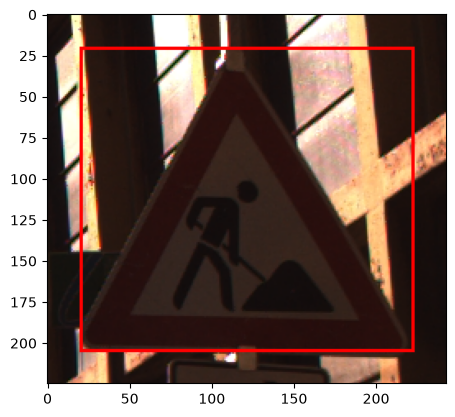

In [8]:
sample_metadata = train_metadata.iloc[28589, :]
sample_img = Image.open(os.path.join(root_dir, sample_metadata["Path"]))

roi_box = ImageDraw.Draw(sample_img)
roi_box.rectangle(
    (
        sample_metadata["Roi.X1"],  # 좌상단 X 좌표
        sample_metadata["Roi.Y1"],  # 좌상단 Y 좌표
        sample_metadata["Roi.X2"],  # 우하단 X 좌표
        sample_metadata["Roi.Y2"],  # 우하단 Y 좌표
    ),
    outline=(255, 0, 0),  # Bounding Box 색을 빨간색으로
    width=2,  # Bounding Box 선의 두께
)

plt.imshow(sample_img)

02. 데이터 분석

In [9]:
train_metadata.head(n=20)

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
5,31,27,6,5,26,22,20,Train/20/00020_00000_00005.png
6,31,28,6,6,26,23,20,Train/20/00020_00000_00006.png
7,31,28,6,6,26,23,20,Train/20/00020_00000_00007.png
8,31,29,5,6,26,24,20,Train/20/00020_00000_00008.png
9,34,32,6,6,29,26,20,Train/20/00020_00000_00009.png


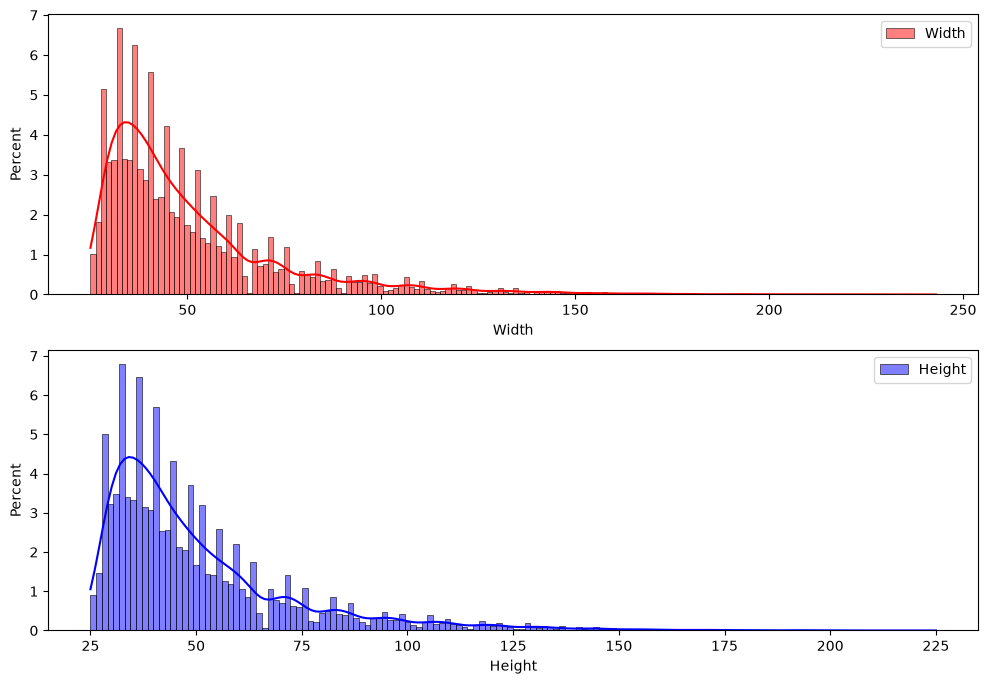

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
sns.set_palette("tab10")
sns.histplot(
    train_metadata,
    x="Width",
    kde=True,
    stat="percent",
    label="Width",
    ax=ax[0],
    color="r",
)
ax[0].legend()
sns.histplot(
    train_metadata,
    x="Height",
    kde=True,
    stat="percent",
    label="Height",
    ax=ax[1],
    color="b",
)
ax[1].legend()

In [11]:
print(
    f"[너비] 평균: {train_metadata['Width'].mean()}\n"
    f"[너비] 중간값(median): {train_metadata['Width'].median()}\n"
    f"[너비] 표준편차: {train_metadata['Width'].std(ddof=0)}"
)
print("=" * 50)
print(
    f"[높이] 평균: {train_metadata['Height'].mean()}\n"
    f"[높이] 중간값(median): {train_metadata['Height'].median()}\n"
    f"[높이] 표준편차: {train_metadata['Height'].std(ddof=0)}"
)

[너비] 평균: 50.83587951745773
[너비] 중간값(median): 43.0
[너비] 표준편차: 24.30662313019728
[높이] 평균: 50.328929582493814
[높이] 중간값(median): 43.0
[높이] 표준편차: 23.115127795106943


In [ ]:
# new1 #
img_height, img_width = 96, 96

03. 데이터셋 구성

In [ ]:
# 기존0 #

# rescale은 입력된 이미지 데이터의 각 픽셀값들을 지정한 수치로 나눠주겠다는 의미입니다.
# 즉 정규화를 의미하는데, 이미지 픽셀은 0 ~ 255의 값을 가지므로 255로 나눠줍니다.

train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    brightness_range=(0.8, 1.2),
    validation_split=0.2,
)

valid_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
    validation_split=0.2,
)


# flow_from_directory를 통해 데이터셋을 생성합니다.
# 클래스 ID별로 저장된 디렉토리 경로명을 처음에 지정해주어야 합니다.

train_set = train_gen.flow_from_directory(
    os.path.join(root_dir, "Train"),
    target_size=(img_height, img_width),
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=True,
    seed=SEED,
    subset="training",
)

valid_set = valid_gen.flow_from_directory(
    os.path.join(root_dir, "Train"),
    target_size=(img_height, img_width),
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    seed=SEED,
    subset="validation",
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [ ]:
print("학습 이미지 수:", train_set.samples)
print("검증 이미지 수:", valid_set.samples)
print("클래스 수:", train_set.num_classes)
print("클래스 매핑:", train_set.class_indices)

In [ ]:
# 기존0 #

# 테스트 파일들의 메타데이터를 DataFrame으로 불러옵니다.
test_metadata = pd.read_csv(os.path.join(root_dir, "Test.csv"))

# flow_from_dataframe 메소드가 클래스 ID에 해당하는 컬럼의 데이터 타입이 문자열(str)이길 요구합니다.
test_metadata["ClassId"] = test_metadata["ClassId"].astype(str)

# 학습 데이터처럼 ImageDataGenerator를 생성합니다.

test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

# flow_from_directory에서는 DataFrame의 어떤 컬럼이 입력(X)이고 어떤 컬럼이 라벨(y)인지 지정해야 합니다.
# 본 데이터셋의 DataFrame은 각각 'Path'와 'ClassId'가 이에 해당합니다.
# 다음으로 각 이미지 파일의 경로는 'directory' argument의 값과 x_col에 지정한 컬럼의 각 값을 join해서 얻어지는데,
# 'Path' 컬럼이 'Test/00000.png'와 같이 이루어져 있으므로 'directory'에는 데이터셋의 최상위 경로만 지정하면 됩니다.

test_set = test_gen.flow_from_dataframe(
    test_metadata,
    directory=root_dir,
    x_col="Path",
    y_col="ClassId",
    target_size=(img_height, img_width),
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
)

Found 12630 validated image filenames belonging to 43 classes.


In [ ]:
print("테스트 이미지 수:", test_set.samples)
print("테스트 CSV 행 수:", len(test_metadata))

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_ids = np.unique(train_set.classes)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_set.classes,
)

class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}

print("클래스 가중치 생성 완료")
print(class_weight)

04. 모델 학습

In [ ]:
# new1 #

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(img_height, img_width, 3)
)

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(43, activation="softmax")(x)

new_model = tf.keras.Model(inputs, outputs)

/home/juny79/.venv/lib/python3.13/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# 기존0 # 

model = tf.keras.Sequential(
    [
        # 특징 추출
        tf.keras.layers.Conv2D(
            filters=5,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(img_height, img_width, 3),
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),
        # 분류
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(43, activation="softmax"),
    ]
)

/home/juny79/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
)

In [55]:
num_epochs = 5
history = model.fit(train_set, epochs=num_epochs, validation_data=valid_set)

Epoch 1/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.1434 - loss: 54.8045 - val_accuracy: 0.1164 - val_loss: 10.0762
Epoch 2/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.0726 - loss: 4.7910 - val_accuracy: 0.0894 - val_loss: 5.8917
Epoch 3/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.0661 - loss: 3.9341 - val_accuracy: 0.0796 - val_loss: 4.7673
Epoch 4/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.0623 - loss: 3.7063 - val_accuracy: 0.0749 - val_loss: 4.2740
Epoch 5/5
246/246 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.0612 - loss: 3.5951 - val_accuracy: 0.0731 - val_loss: 4.0523


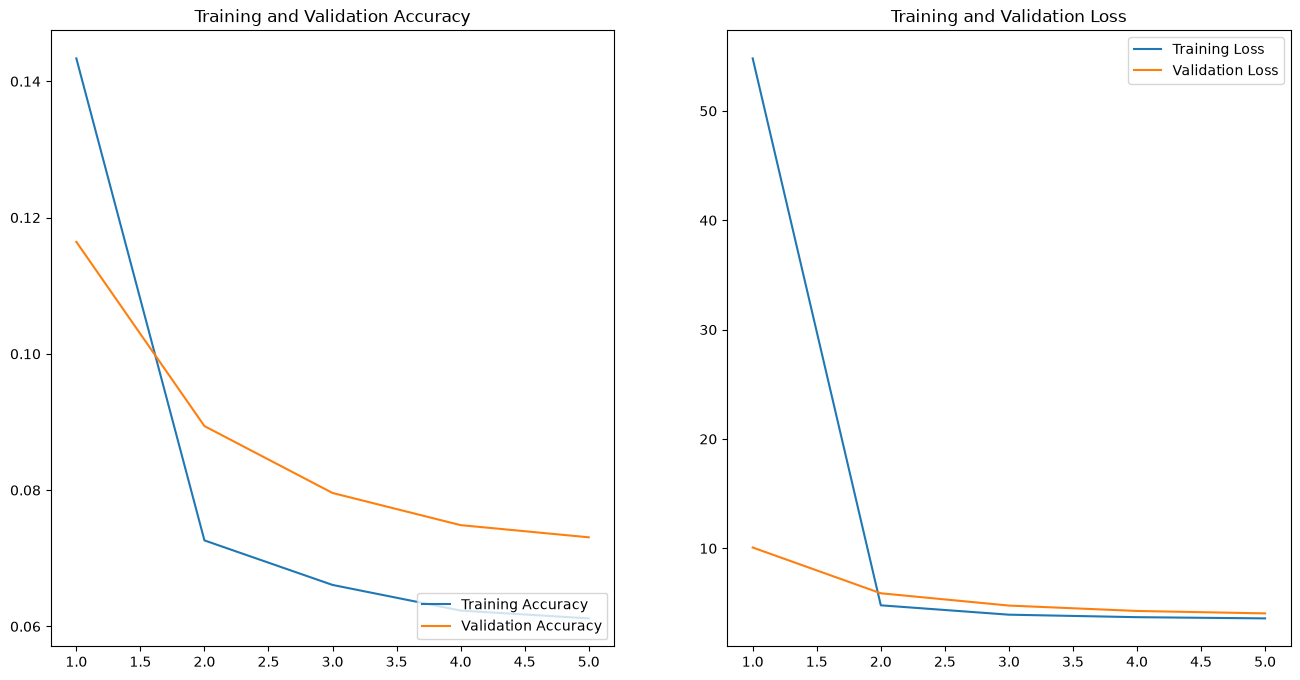

In [56]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

In [57]:
_, test_accuracy = model.evaluate(test_set)
print(f"테스트 정확도: {test_accuracy * 100:.3f}%")

99/99 ━━━━━━━━━━━━━━━━━━━━ 71s 722ms/step - accuracy: 0.0676 - loss: 4.3613
테스트 정확도: 6.762%


99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step


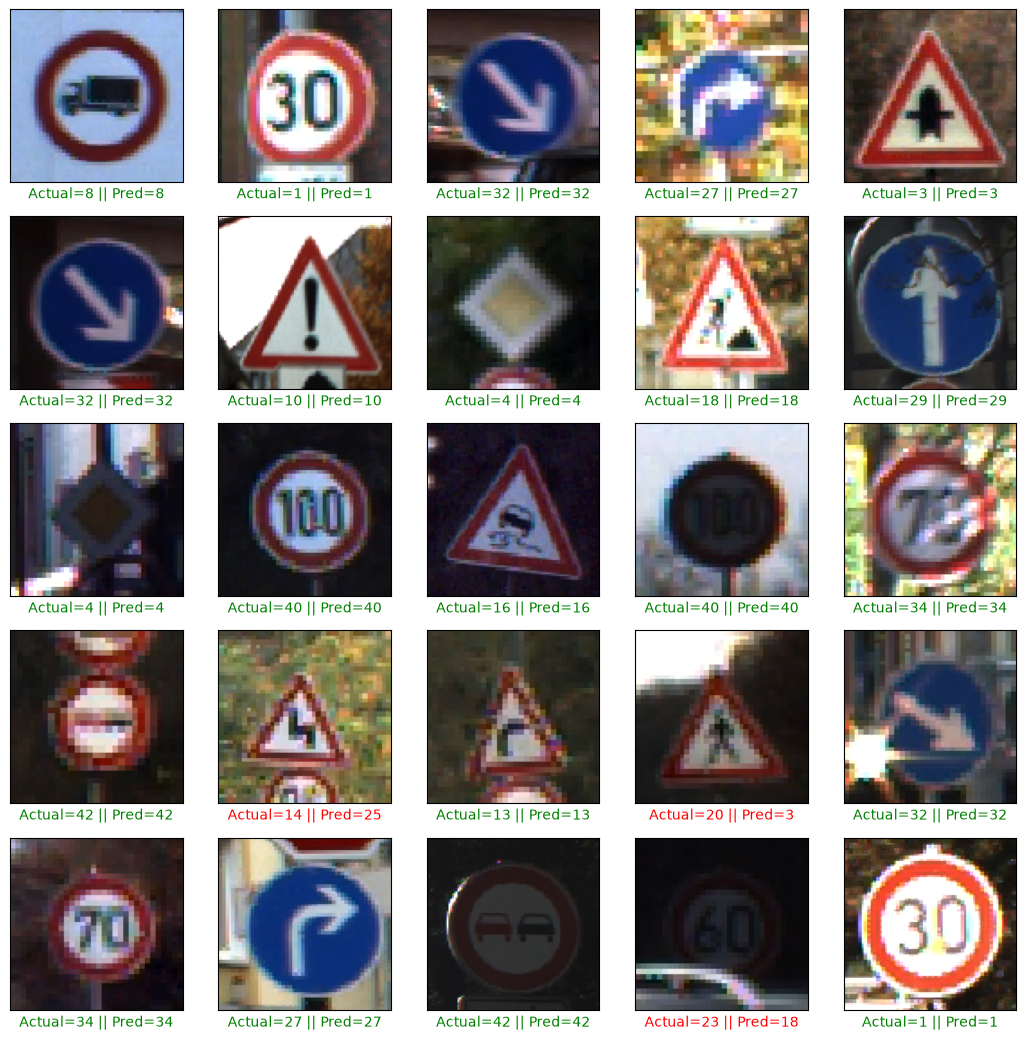

In [36]:
num_sample = 25

test_pred = np.argmax(model.predict(test_set), axis=-1)[:num_sample]
X_test_sample = test_set[0][0][:num_sample, :, :]
y_test_sample = np.argmax(test_set[0][1][:num_sample, :], axis=-1)

plt.figure(figsize=(13, 13))
for i in range(num_sample):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    prediction = test_pred[i]
    actual = y_test_sample[i]
    color = "g"
    if prediction != actual:
        color = "r"

    plt.xlabel(f"Actual={actual} || Pred={prediction}", color=color)
    plt.imshow(tf.keras.utils.array_to_img(X_test_sample[i]))

plt.show()

5. 모델 성능 개선

In [ ]:
device_list = tf.config.list_physical_devices("GPU")
print(f"GPU 사용 가능 여부: {len(device_list) > 0}")
print(device_list)

GPU 사용 가능 여부: True


In [59]:
# [TODO] 데이터셋, 모델을 다각도로 개선하여 정확도를 90% 이상으로 높여보세요.

# 새로운 모델을 구성하고 학습하기 위한 코드를 작성하세요.
# 기존 모델을 그대로 사용하고, 학습 조건만 변경하셔도 무방합니다.
new_model = model

In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(img_height, img_width, 3)
)

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(43, activation="softmax")(x)

new_model = tf.keras.Model(inputs, outputs)

In [ ]:
print("모델 입력 형태:", new_model.input_shape)
print("모델 출력 형태:", new_model.output_shape)

In [ ]:
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),
    metrics=["accuracy"],
)

In [ ]:
new_model.summary()

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_traffic_sign_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
]

In [ ]:
history_stage1 = new_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
)

In [ ]:
valid_loss, valid_accuracy = new_model.evaluate(
    valid_set,
    verbose=1,
)

print(f"검증 손실: {valid_loss:.4f}")
print(f"검증 정확도: {valid_accuracy * 100:.3f}%")

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),
    metrics=["accuracy"],
)

In [ ]:
history_stage2 = new_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks,
)

In [ ]:
new_model = tf.keras.models.load_model(
    "best_traffic_sign_model.keras"
)

print("최적 모델 불러오기 완료")

In [ ]:
print(new_model.input_shape)
print(new_model.output_shape)

In [60]:
# 테스트 데이터셋에서 각 Class ID 별로 할당한 label을 다시 원래 Class ID로 변환하기 위한 inverse map을 구성합니다.
label_map = test_set.class_indices
inverse_label_map = {v: k for k, v in label_map.items()}

In [ ]:
if new_model is None:
    raise ValueError(
        "new_model이 없습니다. 먼저 모델을 생성하고 학습하세요."
    )

label_map = test_set.class_indices
inverse_label_map = {
    value: key
    for key, value in label_map.items()
}

test_set.reset()

predictions = new_model.predict(
    test_set,
    verbose=1,
)

predicted_indices = np.argmax(
    predictions,
    axis=1,
)

predicted_labels = [
    int(inverse_label_map[int(index)])
    for index in predicted_indices
]

In [ ]:
submission = pd.DataFrame(
    {
        "Path": test_metadata["Path"],
        "label": predicted_labels,
    }
)

submission.to_csv(
    "submission_improved.csv",
    index=False,
    encoding="utf-8-sig",
)

print("제출 파일 저장 완료: submission_improved.csv")
print("제출 행 수:", len(submission))
print(submission.head())

In [ ]:
# 기존0 #

# 이 코드를 활용하여 제출 파일을 제작하실 수 있습니다.
# 제출 파일은 'submission.csv'로 저장됩니다.

test_set.reset()

# test_set에 대한 예측 결과를 저장합니다.
test_pred = np.argmax(new_model.predict(test_set), axis=-1)
test_pred = [inverse_label_map[label] for label in test_pred]

test_df = pd.DataFrame(
    {
        "Path": test_metadata["Path"],
        "label": test_pred,
    }
)

test_df.to_csv("submission.csv", index=False)

97/99 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step